In [263]:
from sklearn.datasets import fetch_california_housing 
import pandas as pd

housing = fetch_california_housing(data_home=None, download_if_missing=True, return_X_y=False, as_frame=False) # 获取加州房价数据集
X = pd.DataFrame(data=housing.data, index=None, columns=housing.feature_names, dtype=None, copy=None) # 解释变量
Y = pd.DataFrame(data=housing.target, index=None, columns=housing.target_names, dtype=None, copy=None) # 被解释变量

# 数据处理

原解释变量的数据偏度和峰度都存在一定的问题<br>
| 指标 | 绝对值范围 | 严重程度 | 特征描述 | 常用数据处理方法 |
|:------:|:------------:|:----------:|:----------:|:--------------:|
| 偏度 | < 0.5 | 轻微（近似对称） | 分布基本对称，对多数模型影响小 | 可不处理，或使用 `sqrt(x)`、`log(x+c)` 等缓和变换 |
| 偏度 | 0.5 ~ 1.0 | 中度偏斜 | 明显不对称，可能影响均值的代表性 | 正偏：`log(x)`、`x^0.5`、`x^0.333` 等；负偏：先反射 `max(x)+1-x` 再做对数/平方根，或直接用 Yeo‑Johnson 变换 |
| 偏度 | > 1.0 | 严重偏斜 | 分布高度倾斜，线性模型误差项可能非正态 | 正偏：`log(x)`、`x^0.5`、Box‑Cox；负偏：反射变换或 Yeo‑Johnson；或改用非参数/稳健方法 |
| 超额峰度 | -1~1 | 轻微（接近正态峰） | 尾部厚度与正态分布相近 | 可忽略 |
| 超额峰度 | 1.0 ~ 3.0 或 -3.0 ~ -1.0 | 中等尖峰/厚尾 | 出现少量极端值，方差估计可能不稳 | 对数变换或 Box‑Cox 压缩厚尾；缩尾处理极端值；或使用稳健估计（如中位数、自助法置信区间） |
| 超额峰度 | > 3.0 或 < -3.0 | 严重尖峰/厚尾 | 长尾分布，离群值频发，标准误差膨胀 | 对数/Box‑Cox 变换；缩尾处理；分位数变换（Quantile Transformer）；或改用稳健模型/非参数方法 |

**注意**：超额峰度接近0为正态峰，显著<0（如<-1）为低峰（轻尾），在轻度范围内规则类似。重点关注正向超额峰度（厚尾）。<br>
轻微偏斜：HouseAge、Latitude、Longitude；严重偏斜：MedInc、AveRooms、AveBedrms、Population、AveOccup<br>
轻微：HouseAge；中等尖峰：Latitude、Longitude；严重尖峰：MedInc、AveRooms、AveBedrms、Population、AveOccup<br>
综上，HouseAge、Latitude、Longitude不处理（Latitude、Longitude地理位置信息存在交互效应暂不处理）；MedInc、AveRooms、AveBedrms、Population、AveOccup对数变换<br>

In [264]:
skewness = X.skew(axis=0, skipna=True, numeric_only=False) # 偏度
kurtosis = X.kurtosis(axis=0, skipna=True, numeric_only=False) # 峰度
print(pd.concat(objs=[skewness, kurtosis], axis=1, join="outer", ignore_index=False, keys=["skewness", "kurtosis"], levels=None, 
                names=None, verify_integrity=False, sort=False))

             skewness      kurtosis
MedInc       1.646657      4.952524
HouseAge     0.060331     -0.800629
AveRooms    20.697869    879.353264
AveBedrms   31.316956   1636.711972
Population   4.935858     73.553116
AveOccup    97.639561  10651.010636
Latitude     0.465953     -1.117760
Longitude   -0.297801     -1.330152


## 特征变换

In [265]:
import numpy as np

X[["MedInc_log", "AveRooms_log", "AveBedrms_log", "Population_log", "AveOccup_log"]] = np.log(X[["MedInc", "AveRooms", "AveBedrms", 
                                                                                                         "Population", "AveOccup"]])
X_process = pd.DataFrame(data=None, index=X.index, columns=None, dtype=None, copy=None) # 创建空表，防止未定义警告
X_process[["MedInc_log", "HouseAge", "AveRooms_log", "AveBedrms_log", "Population_log", "AveOccup_log", 
           "Latitude", "Longitude"]] = X[["MedInc_log", "HouseAge", "AveRooms_log", "AveBedrms_log", "Population_log", "AveOccup_log", 
                                          "Latitude", "Longitude"]] # 去除创建空表代码行，在这里尾部加.copy()效果相同
X_process

,MedInc_log,HouseAge,AveRooms_log,AveBedrms_log,Population_log,AveOccup_log,Latitude,Longitude
0,2.119287,41.0,1.943640,0.023530,5.774552,0.938270,37.88,-122.23
1,2.116424,21.0,1.830682,-0.028522,7.783641,0.746613,37.86,-122.22
2,1.982022,52.0,2.114825,0.070874,6.206576,1.030426,37.85,-122.24
3,1.730434,52.0,1.760845,0.070514,6.324359,0.935287,37.85,-122.25
4,1.347086,52.0,1.837665,0.077962,6.336826,0.779998,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,0.444878,25.0,1.618488,0.125163,6.739337,0.940244,39.48,-121.09
20636,0.938756,18.0,1.810587,0.274437,5.874931,1.138732,39.49,-121.21
20637,0.530628,17.0,1.649724,0.113411,6.914731,0.843993,39.43,-121.22
20638,0.624440,18.0,1.673260,0.158643,6.608001,0.752929,39.43,-121.32


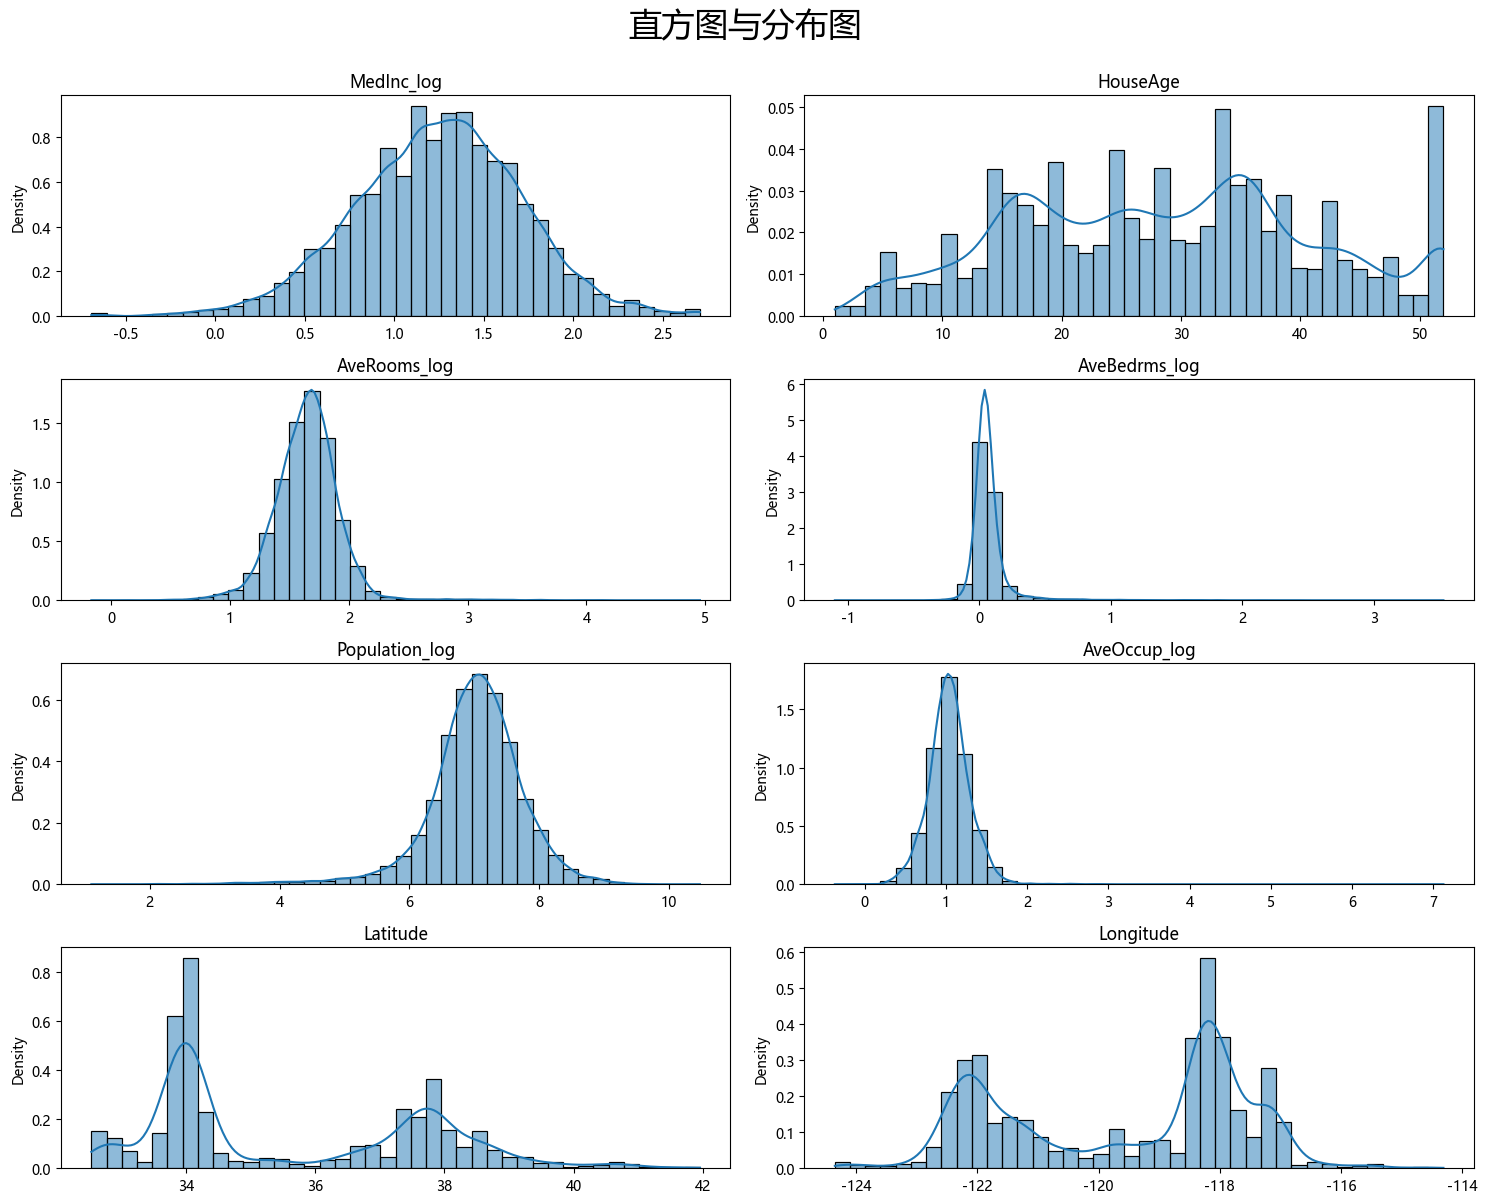

In [266]:
import matplotlib.pyplot as plt
import seaborn as sns
# 设置中文字体（如果系统支持）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'Arial', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15,12))
axes = axes.flatten()
for idx, col in enumerate(X_process.columns):
    sns.histplot(data=X_process, x=col, kde=True, bins=40, ax=axes[idx], stat="density")
    axes[idx].set_title(col)
    axes[idx].set_xlabel('')
plt.suptitle(t="直方图与分布图", y=1, fontsize=24)
plt.tight_layout()
plt.show()

## 标准化
考虑到量纲不同，有些差异过大（尤其是 Latitude 和 Longitude 与其他变量差异过大），因此进行标准化

In [267]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(copy=True, with_mean=True, with_std=True) # 标准化器/模型
X_process_standard = scaler.fit_transform(X=X_process, y=None)
X_process_standard = pd.DataFrame(data=X_process_standard, index=X_process.index, columns=X_process.columns, dtype=None, copy=None)

## 线性回归模型_v0
将处理后的自变量与因变量扔到多元线性回归模型中看看效果：
+ R-squared = 0.608：模型解释了目标变量（房价中位数）约 60.8% 的波动；F-statistic = 3992, P=0.000：模型整体是非常显著的；AIC、BIC 过高，相比于将所有自变量与因变量扔到多元线性回归模型中降低了一些
+ 只有 Population_log 不显著，这意味着在控制了收入、房间数、 occupancy 等因素后，单纯的人口数量对房价没有直接的线性解释力；**正向**：MedInc_log（收入越高房价越高，这是最强的预测因子）、HouseAge（房龄越老房价越高？这点值得注意，见下文）、AveBedrms_log（卧室越多房价越高）；**负向**：Latitude、Longitude（地理位置效应）、AveRooms_log（房间越多房价反而越低？）、AveOccup_log（居住密度越高房价越低）。
+ Omnibus = 3875.248，Prob(Omnibus) = 0.000表明残差不服从正态分布；Skew = 1.022表明残差分布明显右偏，不符合正态分布的对称性；Kurtosis = 5.776表明残差分布具有很厚的尾部，存在较多异常值；DW = 0.952表明残差显著正自相关——残差与滞后一期残差正相关；JB = 10219.510，Prob(JB) = 0.00表明残差不服从正态分布；Cond. No. = 6.51 表明模型非常稳定，没有多重共线性问题。

综上，后续实验考虑
+ 剔除 Population 及其衍生 Population_log
+ 因变量进行对数变换

In [268]:
import statsmodels.api as sm

# 增加截距项，skip会自动检测来判断是否增加一截距项列，当第一列全为1时可能不可靠
X_process_standard_const = sm.add_constant(data=X_process_standard, prepend=True, has_constant="skip") 
model = sm.OLS(endog=Y, exog=X_process_standard_const, missing='none', hasconst=None).fit(method="pinv", 
                                                                         cov_type="nonrobust", 
                                                                         cov_kwds=None, 
                                                                         use_t=None) # 建立线性回归模型并进行拟合
model.summary() # 查看结果

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            MedHouseVal   R-squared:                       0.608
Model:                            OLS   Adj. R-squared:                  0.607
Method:                 Least Squares   F-statistic:                     3992.
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        16:31:48   Log-Likelihood:                -22590.
No. Observations:               20640   AIC:                         4.520e+04
Df Residuals:                   20631   BIC:                         4.527e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              2.0686      0.005    411.004      0.000       2.059       2.078
MedInc_log         0.7480      0.008     89.426      0.000       0.732       0.764
HouseAge           0.1382      0.006     24.722      0.000       0.127       0.149
AveRooms_log      -0.1047      0.009    -11.413      0.000      -0.123      -0.087
AveBedrms_log      0.1517      0.007     21.381      0.000       0.138       0.166
Population_log     0.0024      0.005      0.438      0.661      -0.008       0.013
AveOccup_log      -0.2436      0.005    -45.927      0.000      -0.254      -0.233
Latitude          -0.9360      0.016    -58.677      0.000      -0.967      -0.905
Longitude         -0.8668      0.016    -55.781      0.000      -0.897      -0.836
==============================================================================
Omnibus:                     3875.248   Durbin-Watson:                   0.952
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            10219.510
Skew:                           1.022   Prob(JB):                         0.00
Kurtosis:                       5.776   Cond. No.                         6.51
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 剔除变量并变换因变量

In [269]:
X_process_v1 = X[["MedInc_log", "HouseAge", "AveRooms_log", "AveBedrms_log", "AveOccup_log", "Latitude", "Longitude"]]
scaler_v1 = StandardScaler(copy=True, with_mean=True, with_std=True) # 标准化器/模型
X_process_v1_standard = scaler_v1.fit_transform(X=X_process_v1, y=None)
X_process_v1_standard = pd.DataFrame(data=X_process_v1_standard, index=X_process.index, columns=X_process_v1.columns, dtype=None, copy=None)
Y_process = np.log(Y)

## 线性回归模型_v1

| 指标 | 上一版 (Y原始值) | 这一版 (Y对数变换) | 解读 |
| :---: | :---: | :---: | :---: |
| **R-squared** | 0.608 | 0.673 | 解释力大幅提升。对 Y 取对数后，模型能解释房价波动的 67.3%，这在横截面数据中是非常高的分数。 |
| **Skew** (偏度) | 1.022 | 0.185 | 残差接近正态分布。从 1.0 降到 0.18，说明残差的分布形态变得非常漂亮，基本满足线性回归的假设。 |
| **AIC** | 4.52e+04 | 1.227e+04 | 模型拟合优度极佳。AIC 越低越好，数值大幅下降说明模型在惩罚参数后依然拟合得更好。 |
| **Population** | P=0.661 (不显著) | 已剔除 | 决策正确。去掉了噪音变量，模型更简洁有效。 |

现在的模型变成了 Log-Log 模型（部分变量）或 Lin-Log 模型，这意味着系数的解释方式变了，变得更符合经济学直觉：<br>
**MedInc_log** (系数 0.3871)：弹性系数，在保持其他条件不变的情况下，收入每增加 1%，房价平均上涨约 0.39%；**AveOccup_log** (系数 -0.1068)，居住密度每增加 1%（更拥挤），房价平均下跌约 0.11%，反映了人们对居住空间的追求；**HouseAge** (系数 0.0399)是 Lin-Log 关系（Y是对数，X是原始值），X 每增加 1 个单位（1年），Y 变化 0.0399 ×100%≈4%，房龄每增加 1 年，房价平均上涨约 4%，这依然反映了“地段折旧”效应，即老房子通常占据更好的地段，地段的增值超过了房子的物理折旧；**Latitude & Longitude** 系数依然显著为负，说明地理位置依然是决定房价的基础框架。<br>

依然存在的问题（但已改善）：<br>
**Durbin-Watson** = 1.041，虽然比之前的 0.952 有所提升，但依然远小于 2，空间自相关依然存在。这意味着“邻居还是影响邻居”，对于线性回归来说，这已经是极限了。除非使用空间计量模型（如空间滞后模型），否则很难消除。但在实际应用中，这个 DW 值是可以接受的，只要知道标准误可能偏小即可；**Kurtosis** (峰度) = 6.472，虽然偏度解决了，但峰度依然较高（正态分布应为 3），残差分布依然是“尖峰”的，意味着还有一些极端值（极贵或极便宜的房子）模型没能完美覆盖。不过相比偏度问题，峰度问题的影响较小。

综上，后续实验考虑
+ 纳入 Latitude 与 Longitude 的衍生变量

In [270]:
X_process_v1_standard_const = sm.add_constant(data=X_process_v1_standard, prepend=True, has_constant="skip") 
model = sm.OLS(endog=Y_process, exog=X_process_v1_standard_const, missing='none', hasconst=None).fit(method="pinv", 
                                                                         cov_type="nonrobust", 
                                                                         cov_kwds=None, 
                                                                         use_t=None) # 建立线性回归模型并进行拟合
model.summary() # 查看结果

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            MedHouseVal   R-squared:                       0.673
Model:                            OLS   Adj. R-squared:                  0.673
Method:                 Least Squares   F-statistic:                     6056.
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        16:31:49   Log-Likelihood:                -6129.1
No. Observations:               20640   AIC:                         1.227e+04
Df Residuals:                   20632   BIC:                         1.234e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.5720      0.002    252.294      0.000       0.568       0.576
MedInc_log        0.3871      0.004    102.936      0.000       0.380       0.395
HouseAge          0.0399      0.002     16.532      0.000       0.035       0.045
AveRooms_log     -0.0832      0.004    -20.277      0.000      -0.091      -0.075
AveBedrms_log     0.0866      0.003     27.116      0.000       0.080       0.093
AveOccup_log     -0.1068      0.002    -45.634      0.000      -0.111      -0.102
Latitude         -0.5650      0.007    -78.860      0.000      -0.579      -0.551
Longitude        -0.5171      0.007    -74.006      0.000      -0.531      -0.503
==============================================================================
Omnibus:                     1785.662   Durbin-Watson:                   1.041
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            10481.769
Skew:                           0.185   Prob(JB):                         0.00
Kurtosis:                       6.472   Cond. No.                         6.40
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 特征衍生

### 聚类
对比可得按照经纬度聚类，聚类中心个数为 2 时划分效果最好。

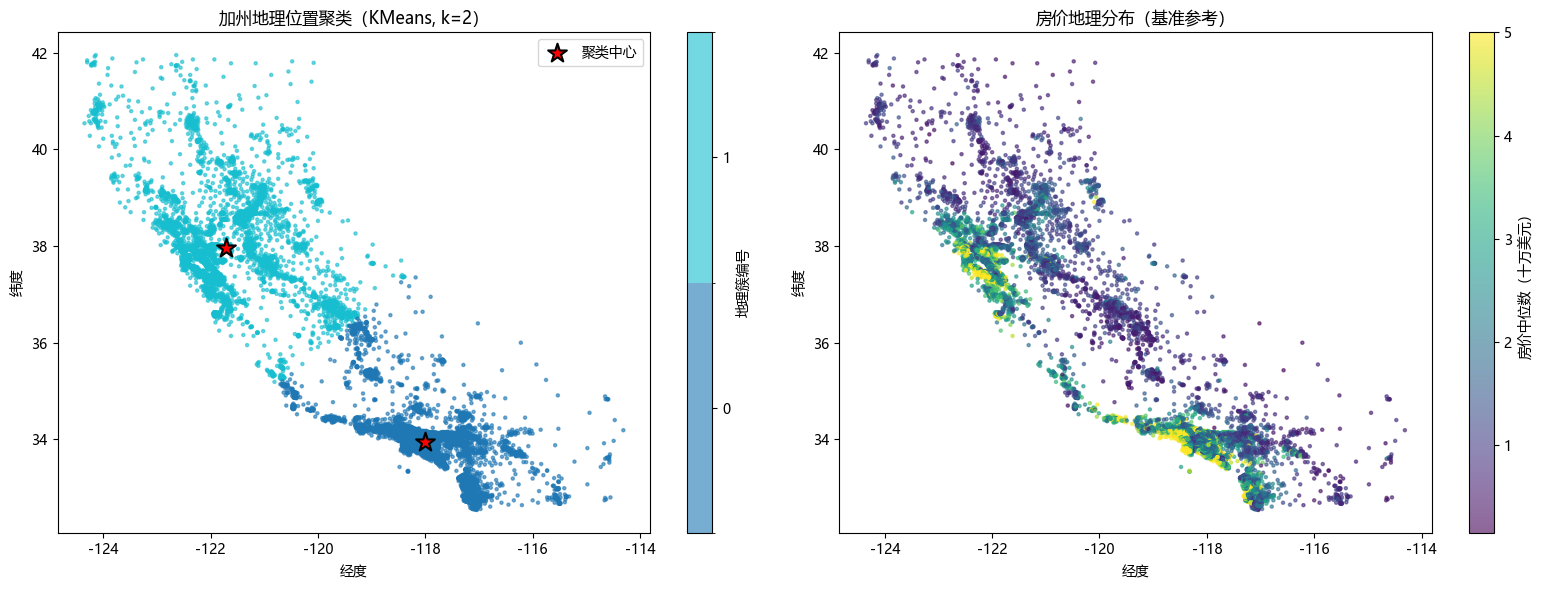

In [271]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm

n_clusters = 2 # 聚类中心个数
kmeans = KMeans(n_clusters=n_clusters, init="k-means++", n_init="auto", max_iter=300, tol=0.0001, verbose=0, random_state=42, 
                    copy_x=True, algorithm="lloyd")
geo_kmeans = kmeans.fit(X=X[["Latitude", "Longitude"]], y=None, sample_weight=None) # 对经纬度聚类

# 提取聚类中心和标签
centers = geo_kmeans.cluster_centers_  # 形状 (n_clusters, 2)，列顺序：[纬度, 经度]
labels = geo_kmeans.labels_

# =================  创建一行两列的子图 =================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---------- 左图：地理位置聚类图 ----------
cmap = plt.get_cmap('tab10', n_clusters)          # 只取前 n_clusters 种颜色
bounds = np.arange(-0.5, n_clusters, 1)       # 边界
norm = BoundaryNorm(boundaries=bounds, ncolors=n_clusters)
# 按聚类标签绘制散点，每个簇一种颜色
scatter = ax1.scatter(x=X['Longitude'], y=X['Latitude'], s=5, c=labels, cmap=cmap, norm=norm, alpha=0.6)
# 绘制聚类中心（星形标记）
ax1.scatter(x=centers[:, 1], y=centers[:, 0], s=200, c='red', marker='*', alpha=1,linewidth=1.5, edgecolors='black', label='聚类中心', zorder=5)

# 颜色条显示簇编号
cbar = plt.colorbar(mappable=scatter, cax=None, ax=ax1, ticks=range(n_clusters))
cbar.set_label('地理簇编号')

# 标签和标题
ax1.set_xlabel('经度')
ax1.set_ylabel('纬度')
ax1.set_title(f'加州地理位置聚类（KMeans, k={n_clusters}）')
ax1.legend()

# ---------- 右图：房价地理分布（基准参考） ----------
sc2 = ax2.scatter(
    x=X['Longitude'], y=X['Latitude'],
    c=Y["MedHouseVal"], cmap="viridis",
    s=5, alpha=0.6
)

cbar2 = plt.colorbar(sc2, ax=ax2)
cbar2.set_label('房价中位数（十万美元）')
ax2.set_xlabel('经度')
ax2.set_ylabel('纬度')
ax2.set_title('房价地理分布（基准参考）')

# 调整布局，防止重叠
plt.tight_layout()
plt.show()

In [272]:
from geopy.distance import geodesic

X["Geo_cluster"] = labels # 地理位置聚类分类变量
centers = pd.DataFrame(data=centers, index=None, columns=["center_lat", "center_lon"], dtype=None,copy=None) # 创建中心点 DataFrame
centers.index.name = "Geo_cluster" # 让索引名为 Geo_cluster，对应簇编号
# 合并：左表用 'Geo_cluster' 列，右表用索引
X = X.merge(right=centers, how="left", on=None, left_on='Geo_cluster', right_on=None, left_index=False, right_index=True, sort=False,
            indicator=False, validate=None)
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedInc_log,AveRooms_log,AveBedrms_log,Population_log,AveOccup_log,Geo_cluster,center_lat,center_lon
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,2.119287,1.943640,0.023530,5.774552,0.938270,1,37.954833,-121.715239
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,2.116424,1.830682,-0.028522,7.783641,0.746613,1,37.954833,-121.715239
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,1.982022,2.114825,0.070874,6.206576,1.030426,1,37.954833,-121.715239
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,1.730434,1.760845,0.070514,6.324359,0.935287,1,37.954833,-121.715239
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,1.347086,1.837665,0.077962,6.336826,0.779998,1,37.954833,-121.715239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.444878,1.618488,0.125163,6.739337,0.940244,1,37.954833,-121.715239
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.938756,1.810587,0.274437,5.874931,1.138732,1,37.954833,-121.715239
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.530628,1.649724,0.113411,6.914731,0.843993,1,37.954833,-121.715239
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.624440,1.673260,0.158643,6.608001,0.752929,1,37.954833,-121.715239


### 构造地理距离特征
按照聚类分类结果以及聚类中心的位置计算各地理类别到聚类中的位置构造**地理距离**特征作为新的特征，使用Haversine 球面距离（单位：公里）来构建距离特征。

In [273]:
def haversine_km(row): # Haversine 球面距离（单位：公里）
    point = (row['Latitude'], row['Longitude'])
    center = (row['center_lat'], row['center_lon'])
    return geodesic(point, center).km
X['dist_to_center_km'] = X.apply(haversine_km, axis=1)

X_process_v2 = X[["MedInc_log", "HouseAge", "AveRooms_log", "AveBedrms_log", "AveOccup_log", "Latitude", "Longitude", "dist_to_center_km"]]
scaler_v2 = StandardScaler(copy=True, with_mean=True, with_std=True) # 标准化器/模型
X_process_v2_standard = scaler_v2.fit_transform(X=X_process_v2, y=None)
X_process_v2_standard = pd.DataFrame(data=X_process_v2_standard, index=X_process.index, columns=X_process_v2.columns, dtype=None, copy=None)

## 线性回归模型_v2
相比于线性回归模型_v1：增加基于经纬度聚类中心的距离衍生特征，整体的 OLS 的结果类似。衍生特征 **dist_to_center_km** 显著，**R-squared**（=0.692） 提高0.019；**F-statistic**值降低但模型整体仍显著（p=0.00）；**AIC/BIC** 显著降低。

In [274]:
X_process_v2_standard_const = sm.add_constant(data=X_process_v2_standard, prepend=True, has_constant="skip") 
model = sm.OLS(endog=Y_process, exog=X_process_v2_standard_const, missing='none', hasconst=None).fit(method="pinv", 
                                                                         cov_type="nonrobust", 
                                                                         cov_kwds=None, 
                                                                         use_t=None) # 建立线性回归模型并进行拟合
model.summary() # 查看结果

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            MedHouseVal   R-squared:                       0.692
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     5807.
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        16:31:54   Log-Likelihood:                -5483.9
No. Observations:               20640   AIC:                         1.099e+04
Df Residuals:                   20631   BIC:                         1.106e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.5720      0.002    260.299      0.000       0.568       0.576
MedInc_log            0.3461      0.004     90.721      0.000       0.339       0.354
HouseAge              0.0219      0.002      9.169      0.000       0.017       0.027
AveRooms_log         -0.0490      0.004    -11.998      0.000      -0.057      -0.041
AveBedrms_log         0.0744      0.003     23.886      0.000       0.068       0.080
AveOccup_log         -0.1141      0.002    -50.098      0.000      -0.119      -0.110
Latitude             -0.5164      0.007    -73.026      0.000      -0.530      -0.503
Longitude            -0.4858      0.007    -71.154      0.000      -0.499      -0.472
dist_to_center_km    -0.0944      0.003    -36.484      0.000      -0.100      -0.089
==============================================================================
Omnibus:                     2051.627   Durbin-Watson:                   1.027
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            12322.992
Skew:                           0.283   Prob(JB):                         0.00
Kurtosis:                       6.743   Cond. No.                         6.64
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""